# Business Intelligence & AI-Assisted Business Insights

## Objective

Notebook ini mengintegrasikan hasil analisis customer, customer segmentation,
churn prediction, dan sales forecasting menjadi business intelligence yang
dapat digunakan untuk mendukung pengambilan keputusan.

## Business Context

Project ini dirancang untuk membantu perusahaan e-commerce memahami:

- customer segments;
- customer churn risk;
- customer value;
- revenue performance;
- revenue forecast;
- dan prioritas tindakan bisnis.

## Input

Notebook menggunakan hasil pemrosesan dari notebook sebelumnya:

- `customer_features.csv`
- `customer_segments.csv`
- hasil churn prediction;
- hasil sales forecasting.

## Methodology

Business insight akan dibangun melalui beberapa tahap:

1. Customer Intelligence
2. Churn Risk Intelligence
3. Revenue Intelligence
4. Business Priority Analysis
5. Business Recommendations

## Important Principle

Perhitungan metric dan business indicator dilakukan menggunakan Python.

AI/LLM, apabila digunakan pada tahap berikutnya, hanya digunakan untuk
menginterpretasikan hasil yang sudah dihitung dan menghasilkan rekomendasi.

LLM tidak digunakan sebagai sumber utama untuk menghitung revenue, churn rate,
customer count, atau metric bisnis lainnya.

## 1. Load Processed Data

Data berikut digunakan sebagai sumber utama business intelligence.

`customer_features.csv` berisi customer-level features yang digunakan pada
analisis customer dan churn.

`customer_segments.csv` berisi hasil customer segmentation dari model
K-Means.

Kedua dataset akan digabungkan menggunakan `customer_id`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

customer_segments = pd.read_csv(
    "../data/processed/customer_segments.csv"
)

completed_transactions = pd.read_csv(
    "../data/processed/completed_transactions.csv"
)

completed_transactions["transaction_date"] = pd.to_datetime(
    completed_transactions["transaction_date"]
)

print("Customer Features:", customer_features.shape)
print("Customer Segments:", customer_segments.shape)
print("Completed Transactions:", completed_transactions.shape)

Customer Features: (10000, 21)
Customer Segments: (10000, 6)
Completed Transactions: (68700, 13)


## 2. Integrate Customer Intelligence

Customer features dan customer segmentation digabungkan menjadi satu
customer intelligence dataset.

Dataset ini menjadi dasar untuk menganalisis:

- customer value;
- purchasing behavior;
- engagement;
- customer segment;
- dan churn-related indicators.

`customer_id` digunakan sebagai key untuk memastikan setiap customer
direpresentasikan satu kali.

In [2]:
customer_intelligence = customer_features.merge(
    customer_segments[
        [
            "customer_id",
            "cluster",
            "business_segment"
        ]
    ],
    on="customer_id",
    how="left",
    validate="one_to_one"
)

print("Customer Intelligence Shape:", customer_intelligence.shape)

display(
    customer_intelligence.head()
)

Customer Intelligence Shape: (10000, 23)


,customer_id,age,gender,country,email_opt_in,has_app,is_churned,recency_days,frequency,monetary,...,tenure_days,total_sessions,avg_session_duration,avg_pages_viewed,total_cart_additions,conversion_rate,bounce_rate,has_purchase,cluster,business_segment
0,C00000,28,M,BR,0,0,0,5.0,18.0,706.65,...,1783,8.0,696.875000,10.750000,5.0,0.125000,0.125000,1,1,Champions
1,C00001,22,Prefer not to say,FR,1,0,0,8.0,5.0,244.64,...,1187,12.0,325.500000,6.833333,4.0,0.000000,0.083333,1,2,Potential Loyalists
2,C00002,30,F,US,1,1,0,171.0,16.0,1104.66,...,919,29.0,439.896552,7.482759,31.0,0.103448,0.068966,1,4,Loyal Customers
3,C00003,48,F,US,1,0,1,8.0,15.0,695.06,...,1106,17.0,284.588235,5.176471,20.0,0.117647,0.176471,1,1,Champions
4,C00004,37,M,CA,0,1,0,258.0,2.0,148.32,...,1202,1.0,216.000000,5.000000,0.0,0.000000,0.000000,1,3,Dormant / Low Value


## 3. Customer Segment Performance

Hasil customer segmentation akan dianalisis berdasarkan:

- jumlah customer;
- total revenue;
- average revenue per customer;
- average purchase frequency;
- dan average recency.

Tujuannya adalah mengetahui kontribusi ekonomi setiap customer segment
dan menentukan segment yang perlu dipertahankan, dikembangkan, atau
diaktifkan kembali.

In [3]:
segment_performance = (
    customer_intelligence
    .groupby("business_segment")
    .agg(
        customer_count=("customer_id", "count"),
        total_revenue=("monetary", "sum"),
        average_revenue=("monetary", "mean"),
        average_frequency=("frequency", "mean"),
        average_recency=("recency_days", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

segment_performance

,business_segment,customer_count,total_revenue,average_revenue,average_frequency,average_recency
3,Loyal Customers,2709,2159549.85,797.176024,9.559616,98.609081
1,Champions,1577,1856665.10,1177.339949,13.599239,18.241598
0,At Risk,2651,819731.71,309.216035,4.313844,193.228970
5,Potential Loyalists,1433,511156.70,356.703908,5.293789,24.545010
2,Dormant / Low Value,1360,96144.68,70.694618,1.716912,317.117647
4,No Purchase,270,0.00,0.000000,0.000000,NaN


## 4. Segment Revenue Visualization

Visualisasi digunakan untuk membandingkan kontribusi revenue setiap
customer segment.

Tujuannya adalah mengidentifikasi segment yang memiliki kontribusi ekonomi
terbesar dan segment yang membutuhkan perhatian bisnis.

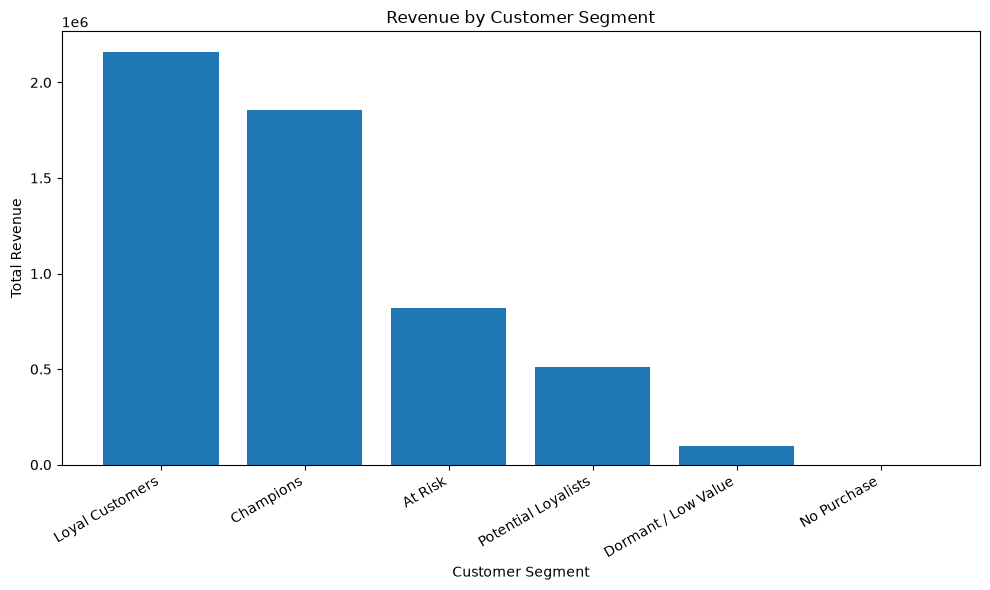

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_performance["business_segment"],
    segment_performance["total_revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 5. Churn Risk Integration

Customer segmentation menunjukkan nilai dan perilaku pelanggan,
sedangkan churn prediction menunjukkan kemungkinan pelanggan berhenti
bertransaksi.

Pada tahap ini, kedua informasi tersebut akan digabungkan untuk
mengidentifikasi pelanggan yang memiliki risiko churn sekaligus memiliki
nilai bisnis yang tinggi.

Output churn berasal dari hasil evaluasi model pada test set.

Tujuannya adalah membantu menentukan prioritas retention secara lebih
terarah.

In [8]:
# Memuat hasil prediksi churn dari Notebook 06.

churn_risk = pd.read_csv("../data/processed/churn_risk.csv")

print("Churn Risk Shape:", churn_risk.shape)
display(churn_risk.head())

Churn Risk Shape: (2000, 9)


,customer_id,churn_probability,risk_level,monetary,frequency,recency_days,has_purchase,customer_value,priority
0,C04363,0.725025,High Risk,717.66,5.0,176.0,True,High Value,High Priority
1,C07600,0.719262,High Risk,451.22,3.0,249.0,True,High Value,High Priority
2,C09239,0.713074,High Risk,637.77,2.0,234.0,True,High Value,High Priority
3,C05748,0.705911,High Risk,452.95,1.0,725.0,True,High Value,High Priority
4,C09541,0.701615,High Risk,1733.02,2.0,426.0,True,High Value,High Priority


### Integrasi Customer Intelligence dan Churn Risk

Dataset customer intelligence akan digabungkan dengan hasil prediksi
churn berdasarkan `customer_id`.

Hasil integrasi digunakan untuk menghubungkan:
- customer segment
- customer value
- purchase behavior
- churn probability
- churn risk level
- retention priority

In [ ]:
customer_bi = customer_intelligence.merge(
    churn_risk,
    on="customer_id",
    how="inner",
    validate="one_to_one"
)

# Memeriksa kolom hasil integrasi sebelum memilih kolom untuk ditampilkan.
print("Customer BI Shape:", customer_bi.shape)
print("\nKolom Customer BI:")
print(customer_bi.columns.tolist())

# Menampilkan kolom utama hasil integrasi customer intelligence dan churn risk.

display(
    customer_bi[
        [
            "customer_id",
            "business_segment",
            "monetary_x",
            "frequency_x",
            "recency_days_x",
            "churn_probability",
            "risk_level",
            "customer_value",
            "priority",
        ]
    ].head(10)
)

Customer BI Shape: (2000, 31)

Kolom Customer BI:
['customer_id', 'age', 'gender', 'country', 'email_opt_in', 'has_app', 'is_churned', 'recency_days_x', 'frequency_x', 'monetary_x', 'total_orders', 'total_quantity', 'average_order_value', 'tenure_days', 'total_sessions', 'avg_session_duration', 'avg_pages_viewed', 'total_cart_additions', 'conversion_rate', 'bounce_rate', 'has_purchase_x', 'cluster', 'business_segment', 'churn_probability', 'risk_level', 'monetary_y', 'frequency_y', 'recency_days_y', 'has_purchase_y', 'customer_value', 'priority']


KeyError: "['monetary', 'frequency', 'recency_days'] not in index"